# Analyzing COVID-19 Papers

In this challenge, we will continue with the topic of COVID pandemic, and focus on processing scientific papers on the subject. There is [CORD-19 Dataset](https://www.kaggle.com/allen-institute-for-ai/CORD-19-research-challenge) with more than 7000 (at the time of writing) papers on COVID, available with metadata and abstracts (and for about half of them there is also full text provided).

A full example of analyzing this dataset using [Text Analytics for Health](https://docs.microsoft.com/azure/cognitive-services/text-analytics/how-tos/text-analytics-for-health/?WT.mc_id=academic-77958-bethanycheum) cognitive service is described [in this blog post](https://soshnikov.com/science/analyzing-medical-papers-with-azure-and-text-analytics-for-health/). We will discuss simplified version of this analysis.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Getting the Data

First, we need get the metadata for CORD papers that we will be working with.

**NOTE**: We do not provide a copy of the dataset as part of this repository. You may first need to download the [`metadata.csv`](https://www.kaggle.com/allen-institute-for-ai/CORD-19-research-challenge?select=metadata.csv) file from [this dataset on Kaggle](https://www.kaggle.com/allen-institute-for-ai/CORD-19-research-challenge). Registration with Kaggle may be required. You may also download the dataset without registration [from here](https://ai2-semanticscholar-cord-19.s3-us-west-2.amazonaws.com/historical_releases.html), but it will include all full texts in addition to metadata file.

We will try to get the data directly from online source, however, if it fails, you need to download the data as described above. Also, it makes sense to download the data if you plan to experiment with it further, to save on waiting time.

> **NOTE** that dataset is quite large, around 1 Gb in size, and the following line of code can take a long time to complete! (~5 mins)

In [12]:
df = pd.read_csv("sample_data/metadata.csv",engine='python', on_bad_lines='skip')
# df = pd.read_csv("metadata.csv")
df.head()

,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
3,2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,PMC,Role of endothelin-1 in lung disease,10.1186/rr44,PMC59574,11686871,no-cc,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001-02-22,"Fagan, Karen A; McMurtry, Ivan F; Rodman, David M",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/348055649b6b8cf2b9a37...,document_parses/pmc_json/PMC59574.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
4,9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,PMC,Gene expression in epithelial cells in respons...,10.1186/rr61,PMC59580,11686888,no-cc,Respiratory syncytial virus (RSV) and pneumoni...,2001-05-11,"Domachowske, Joseph B; Bonville, Cynthia A; Ro...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/5f48792a5fa08bed9f560...,document_parses/pmc_json/PMC59580.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN


In [13]:
print(df.columns.tolist())

['cord_uid', 'sha', 'source_x', 'title', 'doi', 'pmcid', 'pubmed_id', 'license', 'abstract', 'publish_time', 'authors', 'journal', 'mag_id', 'who_covidence_id', 'arxiv_id', 'pdf_json_files', 'pmc_json_files', 'url', 's2_id']


In [14]:
df = pd.read_csv("sample_data/metadata.csv", engine='python', on_bad_lines='skip', quoting=3)
print(df.columns.tolist()[:10])

['cord_uid', 'sha', 'source_x', 'title', 'doi', 'pmcid', 'pubmed_id', 'license', 'abstract', 'publish_time']


In [15]:
cols = ['cord_uid', 'sha', 'source_x', 'title', 'doi', 'pmcid', 'pubmed_id',
        'license', 'abstract', 'publish_time', 'authors', 'journal',
        'mag_id', 'who_covidence_id', 'arxiv_id', 'pdf_json_files',
        'pmc_json_files', 'url', 's2_id']

df = pd.read_csv("metadata.csv", engine='python', on_bad_lines='skip',
                 names=cols, skiprows=1)
print(df.columns.tolist())
print(df.shape)
df.head()

['cord_uid', 'sha', 'source_x', 'title', 'doi', 'pmcid', 'pubmed_id', 'license', 'abstract', 'publish_time', 'authors', 'journal', 'mag_id', 'who_covidence_id', 'arxiv_id', 'pdf_json_files', 'pmc_json_files', 'url', 's2_id']
(1003121, 19)


,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,m9j6yw58,NaN,PMC,"Zi fordert Strategie der Testung, Kontaktverfo...",10.1007/s15011-020-3396-2,PMC7720444,NaN,no-cc,NaN,2020-12-15,"Hardt, Wolfgang",Dtsch Dermatolog,NaN,NaN,NaN,NaN,NaN,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7...,NaN
1,xpfobjz2,6126ada9c2046248065cc1a8f375834d40c5bc7d,PMC,Informal urbanism in the state of uncertainty:...,10.1057/s41289-020-00145-3,PMC7720475,NaN,no-cc,Forms of informality—ranging from informal set...,2020-12-07,"Kamalipour, Hesam; Peimani, Nastaran",Urban Des Int,NaN,NaN,NaN,document_parses/pdf_json/6126ada9c2046248065cc...,document_parses/pmc_json/PMC7720475.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7...,NaN
2,r6edyjfs,NaN,PMC,GeSRU,10.1007/s00120-020-01384-6,PMC7720781,NaN,no-cc,NaN,2020-12-07,NaN,Urologe A,NaN,NaN,NaN,NaN,NaN,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7...,NaN
3,nlknwp5y,NaN,PMC,Data-Driven Approaches to Integrated Disaster ...,10.1007/s13753-020-00324-4,PMC7720785,NaN,cc-by,NaN,2020-12-07,"Lemiale, Vincent; Prakash, Mahesh; Cruz, Ana M...",Int J Disaster Risk Sci,NaN,NaN,NaN,NaN,NaN,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7...,NaN
4,aqm09e8n,NaN,PMC,Infektiologie,10.1007/s00120-020-01372-w,PMC7720786,NaN,no-cc,NaN,2020-12-07,"Kranz, Jennifer; Wagenlehner, Florian M. E.",Urologe A,NaN,NaN,NaN,NaN,NaN,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7...,NaN


We will now convert publication date column to `datetime`, and plot the histogram to see the range of publication dates.

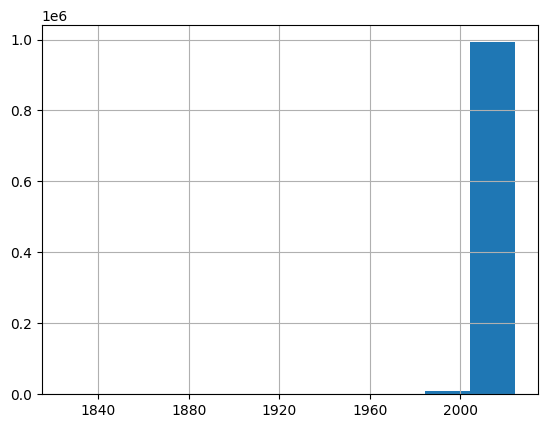

In [16]:
df['publish_time'] = pd.to_datetime(df['publish_time'],format='mixed', errors='coerce')
df['publish_time'].hist()
plt.show()

Interestingly, there are coronavirus-related papers that date back to 1880!

## Structured Data Extraction

Let's see what kind of information we can easily extract from abstracts. One thing we might be interested in is to see which treatment strategies exist, and how they evolved over time. To begin with, we can manually compile the list of possible medications used to treat COVID, and also the list of diagnoses. We then go over them and search corresponding terms in the abstracts of papers.

In [17]:
medications = [
    'hydroxychloroquine', 'chloroquine', 'tocilizumab', 'remdesivir', 'azithromycin',
    'lopinavir', 'ritonavir', 'dexamethasone', 'heparin', 'favipiravir', 'methylprednisolone']
diagnosis = [
    'covid','sars','pneumonia','infection','diabetes','coronavirus','death'
]

for m in medications:
    print(f" + Processing medication: {m}")
    df[m] = df['abstract'].apply(lambda x: str(x).lower().count(' '+m))

for m in diagnosis:
    print(f" + Processing diagnosis: {m}")
    df[m] = df['abstract'].apply(lambda x: str(x).lower().count(' '+m))

 + Processing medication: hydroxychloroquine
 + Processing medication: chloroquine
 + Processing medication: tocilizumab
 + Processing medication: remdesivir
 + Processing medication: azithromycin
 + Processing medication: lopinavir
 + Processing medication: ritonavir
 + Processing medication: dexamethasone
 + Processing medication: heparin
 + Processing medication: favipiravir
 + Processing medication: methylprednisolone
 + Processing diagnosis: covid
 + Processing diagnosis: sars
 + Processing diagnosis: pneumonia
 + Processing diagnosis: infection
 + Processing diagnosis: diabetes
 + Processing diagnosis: coronavirus
 + Processing diagnosis: death


We have added a bunch of columns to our dataframe that contain number of times a given medicine/diagnosis is present in the abstract.

> **Note** that we add space to the beginning of the word when looking for a substring. If we do not do that, we might get wrong results, because *chloroquine* would also be found inside substring *hydroxychloroquine*. Also, we force conversion of abstracts column to `str` to get rid of an error - try removing `str` and see what happens.

To make working with data easier, we can extract the sub-frame with only medication counts, and compute the accumulated number of occurrences. This gives is the most popular medication:

In [18]:
dfm = df[medications]
dfm = dfm.sum().reset_index().rename(columns={ 'index' : 'Name', 0 : 'Count'})
dfm.sort_values('Count',ascending=False)

,Name,Count
0,hydroxychloroquine,11122
3,remdesivir,10654
2,tocilizumab,7892
8,heparin,5434
1,chloroquine,5122
7,dexamethasone,5012
5,lopinavir,4307
4,azithromycin,4287
9,favipiravir,3334
10,methylprednisolone,2296


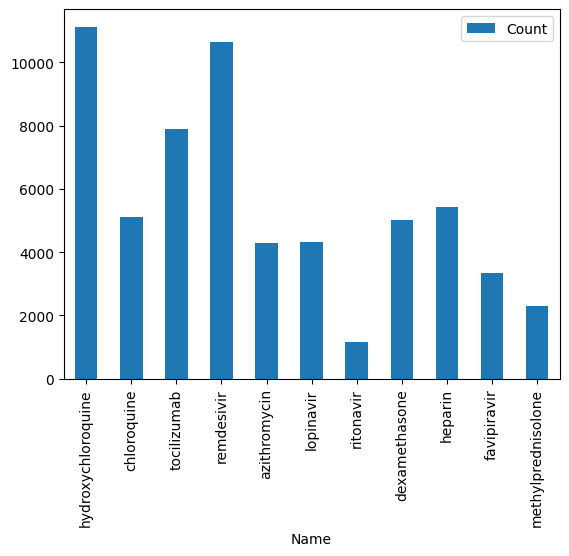

In [19]:
dfm.set_index('Name').plot(kind='bar')
plt.show()

## Looking for Trends in Treatment Strategy

In the example above we have `sum`ed all values, but we can also do the same on a monthly basis:

In [20]:
dfm = df[['publish_time']+medications].set_index('publish_time')
dfm = dfm[(dfm.index>="2020-01-01") & (dfm.index<="2021-07-31")]
dfmt = dfm.groupby([dfm.index.year,dfm.index.month]).sum()
dfmt

hydroxychloroquine  chloroquine  tocilizumab  \
publish_time publish_time                                                 
2020         1                           3884         1976         1911   
             2                              0            8            0   
             3                             46           73            5   
             4                            183          235           49   
             5                            447          184          158   
             6                            379          142          243   
             7                            378          174          203   
             8                            309          114          175   
             9                            318          124          188   
             10                           307           94          210   
             11                           265           66          168   
             12                           254          108          228   
2021         1                           2466          877         2165   
             2                            164           66          184   
             3                            175           84          187   
             4                            199           65          122   
             5                            152           55          138   
             6                            144           30          146   
             7                            115           44           96   

                           remdesivir  azithromycin  lopinavir  ritonavir  \
publish_time publish_time                                                   
2020         1                   2279          1223       1549        403   
             2                      3             2         17         11   
             3                     29            12         51         16   
             4                    118            68        112         13   
             5                    204           127        134         41   
             6                    185           110        132         17   
             7                    173           108        138         29   
             8                    172           146         93         24   
             9                    189            89         96         28   
             10                   227            89        126         39   
             11                   201            77        106         27   
             12                   267            98         75         30   
2021         1                   2877          1072        932        214   
             2                    180            84         76          9   
             3                    301            89        101         18   
             4                    167            89         60         13   
             5                    182            70         56         22   
             6                    180            73         47         14   
             7                    252            83         52          4   

                           dexamethasone  heparin  favipiravir  \
publish_time publish_time                                        
2020         1                       598     1025          730   
             2                         1        0           11   
             3                         2       18           11   
             4                        14       78           47   
             5                        10       93           45   
             6                        48       83           30   
             7                        58      115           56   
             8                        56       89           43   
             9                        90      111           46   
             10                      100      117           79   
             11                       83 

This gives us a good picture of treatment strategies. Let's visualize it!

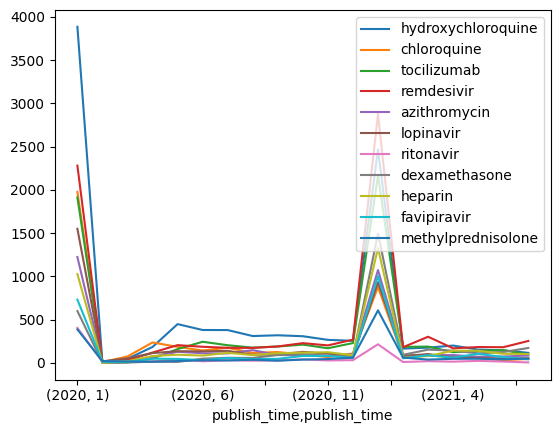

In [21]:
dfmt.plot()
plt.show()

An interesting observation is that we have huge spikes at two locations: January, 2020 and January, 2021. It is caused by the fact that some papers do not have a clearly specified data of publication, and they are specified as January of the respective year.

To make more sense of the data, let's visualize just a few medicines. We will also "erase" data for January, and fill it in by some medium value, in order to make nicer plot:

/tmp/ipykernel_1150/1877372667.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dfmt.fillna(method='pad',inplace=True)


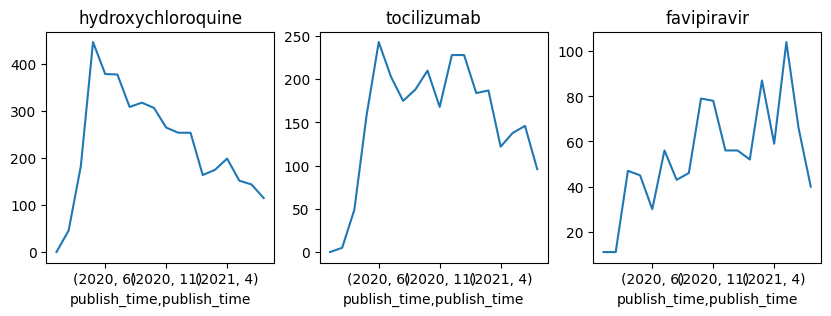

In [22]:
meds = ['hydroxychloroquine','tocilizumab','favipiravir']
dfmt.loc[(2020,1)] = np.nan
dfmt.loc[(2021,1)] = np.nan
dfmt.fillna(method='pad',inplace=True)
fig, ax = plt.subplots(1,len(meds),figsize=(10,3))
for i,m in enumerate(meds):
    dfmt[m].plot(ax=ax[i])
    ax[i].set_title(m)
plt.show()

Observe how popularity of hydroxychloroquine was on the rise in the first few months, and then started to decline, while number of mentions of favipiravir shows stable rise. Another good way to visualize relative popularity is to use **stack plot** (or **area plot** in Pandas terminology):

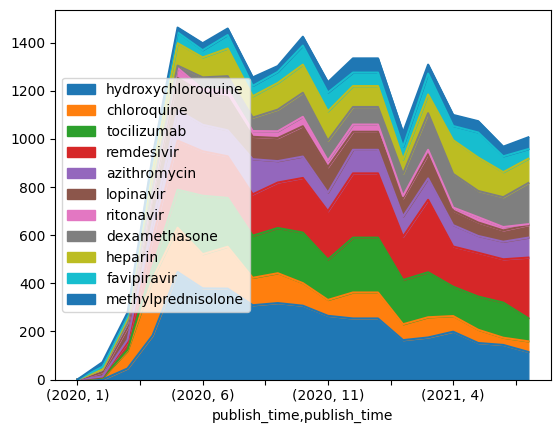

In [23]:
dfmt.plot.area()
plt.show()

Even further, we can compute relative popularity in percents:

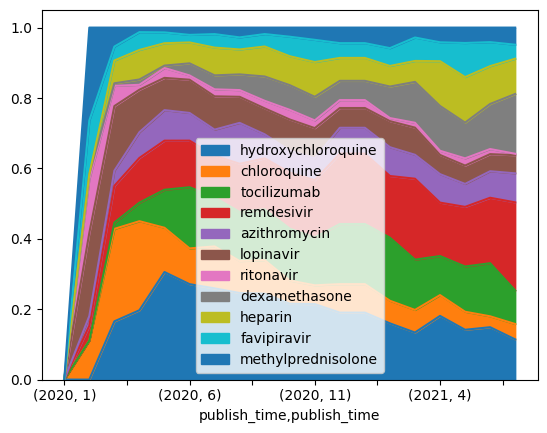

In [24]:
dfmtp = dfmt.iloc[:,:].apply(lambda x: x/x.sum(), axis=1)
dfmtp.plot.area()
plt.show()


## Computing Medicine-Diagnosis Correspondence

One of the most interesting relationships we can look for is how different diagnoses are treated with different medicines. In order to visualize it, we need to compute **co-occurence frequency map**, which would show how many times two terms are mentioned in the same paper.

Such a map is essentially a 2D matrix, which is best represented by **numpy array**. We will compute this map by walking through all abstracts, and marking entities that occur there:

In [25]:
m = np.zeros((len(medications),len(diagnosis)))
for a in df['abstract']:
    x = str(a).lower()
    for i,d in enumerate(diagnosis):
        if ' '+d in x:
            for j,me in enumerate(medications):
                if ' '+me in x:
                    m[j,i] += 1

In [26]:
m

array([[5461., 2580.,  811., 2374.,  386., 3030., 1079.],
       [2366., 1374.,  258., 1063.,   90., 1549.,  403.],
       [2736., 1007.,  832., 1338.,  236., 1332.,  677.],
       [4274., 2797.,  717., 2069.,  241., 2669.,  815.],
       [2159.,  927.,  466., 1054.,  177., 1029.,  479.],
       [2241., 1237.,  422.,  974.,  122., 1491.,  406.],
       [ 593.,  428.,   87.,  300.,   22.,  409.,  122.],
       [2163.,  916.,  516., 1096.,  177., 1017.,  459.],
       [2031.,  875.,  425.,  986.,  134.,  993.,  359.],
       [1254.,  789.,  249.,  560.,   55.,  802.,  169.],
       [1006.,  473.,  390.,  561.,   99.,  580.,  202.]])

One of the ways to visualize this matrix is to draw a **heatmap**:

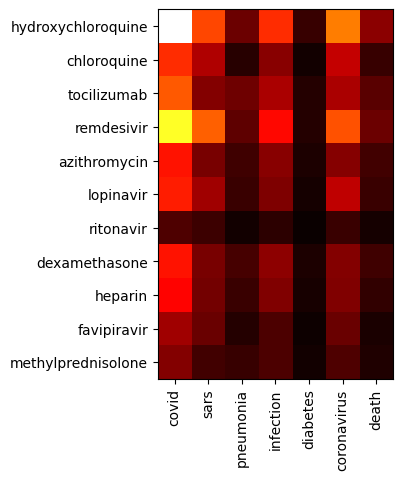

In [27]:
plt.imshow(m,interpolation='nearest',cmap='hot')
ax = plt.gca()
ax.set_yticks(range(len(medications)))
ax.set_yticklabels(medications)
ax.set_xticks(range(len(diagnosis)))
ax.set_xticklabels(diagnosis,rotation=90)
plt.show()

However, even better visualization can be done using so-called **Sankey** diagram! `matplotlib` does not have built-in support for this diagram type, so we would have to use [Plotly](https://plotly.com/python/) as described [in this tutorial](https://plotly.com/python/sankey-diagram/).

To make plotly sankey diagram, we need to build the following lists:
* List `all_nodes` of all nodes in the graph, which will include both medications and diagnosis
* List of source and target indices - those lists would show, which nodes go to the left, and which to the right part of the diagram
* List of all links, each link consisting of:
   - Source index in the `all_nodes` array
   - Target index
   - Value indicating strength of the link. This is exactly the value from our co-occurence matrix.
   - Optionally color of the link. We will make an option to highlight some of the terms for clarity

Generic code to draw sankey diagram is structured as a separate `sankey` function, which takes two lists (source and target categories) and co-occurence matrix. It also allows us to specify the threshold, and omit all links that are weaker than that threshold - this makes the diagram a little bit less complex.

In [28]:
import plotly.graph_objects as go

def sankey(cat1, cat2, m, treshold=0, h1=[], h2=[]):
    all_nodes = cat1 + cat2
    source_indices = list(range(len(cat1)))
    target_indices = list(range(len(cat1),len(cat1)+len(cat2)))

    s, t, v, c = [], [], [], []
    for i in range(len(cat1)):
        for j in range(len(cat2)):
            if m[i,j]>treshold:
                s.append(i)
                t.append(len(cat1)+j)
                v.append(m[i,j])
                c.append('pink' if i in h1 or j in h2 else 'lightgray')

    fig = go.Figure(data=[go.Sankey(
        # Define nodes
        node = dict(
        pad = 40,
        thickness = 40,
        line = dict(color = "black", width = 1.0),
        label =  all_nodes),

        # Add links
        link = dict(
        source =  s,
        target =  t,
        value =  v,
        color = c
    ))])
    fig.show()

sankey(medications,diagnosis,m,500,h2=[0])

## Conclusion

You have seen that we can use quite simple methods to extract information from non-structured data sources, such as text. In this example, we have taken the existing list of medications, but it would be much more powerful to use natural language processing (NLP) techniques to perform entity extraction from text. In [this blog post](https://soshnikov.com/science/analyzing-medical-papers-with-azure-and-text-analytics-for-health/) we describe how to use cloud services for entity extraction. Another option would be using Python NLP libraries such as [NLTK](https://www.nltk.org/) - an approach for extracting information from text using NLTK is described [here](https://www.nltk.org/book/ch07.html).

## Challenge

Continue to research the COVID paper data along the following lines:

1. Build co-occurrence matrix of different medications, and see which medications often occur together (i.e. mentioned in one abstract). You can modify the code for building co-occurrence matrix for medications and diagnoses.
1. Visualize this matrix using heatmap.
1. As a stretch goal, you may want to visualize the co-occurrence of medications using [chord diagram](https://en.wikipedia.org/wiki/Chord_diagram). [This library](https://pypi.org/project/chord/) may help you draw a chord diagram.
1. As another stretch goal, try to extract dosages of different medications (such as **400mg** in *take 400mg of chloroquine daily*) using regular expressions, and build dataframe that shows different dosages for different medications. **Note**: consider numeric values that are in close textual vicinity of the medicine name.

In [29]:
# Task 1: Co-occurrence matrix for medications
medications = ['hydroxychloroquine', 'chloroquine', 'remdesivir', 'dexamethasone',
               'azithromycin', 'lopinavir', 'ritonavir', 'heparin',
               'favipiravir', 'methylprednisolone']

# Build medication occurrence columns
for med in medications:
    df[med] = df['abstract'].str.contains(' '+med, case=False, na=False).astype(int)

# Build co-occurrence matrix
co_matrix = pd.DataFrame(index=medications, columns=medications, data=0)

for i, med1 in enumerate(medications):
    for j, med2 in enumerate(medications):
        co_matrix.loc[med1, med2] = (df[med1] & df[med2]).sum()

print(co_matrix)

                    hydroxychloroquine  chloroquine  remdesivir  \
hydroxychloroquine                6288         1650        1221   
chloroquine                       1650         2933         738   
remdesivir                        1221          738        5108   
dexamethasone                      305          123         821   
azithromycin                      1592          506         393   
lopinavir                         1194          655         911   
ritonavir                          284          200         246   
heparin                            144           34         147   
favipiravir                        544          336         679   
methylprednisolone                 117           18          99   

                    dexamethasone  azithromycin  lopinavir  ritonavir  \
hydroxychloroquine            305          1592       1194        284   
chloroquine                   123           506        655        200   
remdesivir                    821          

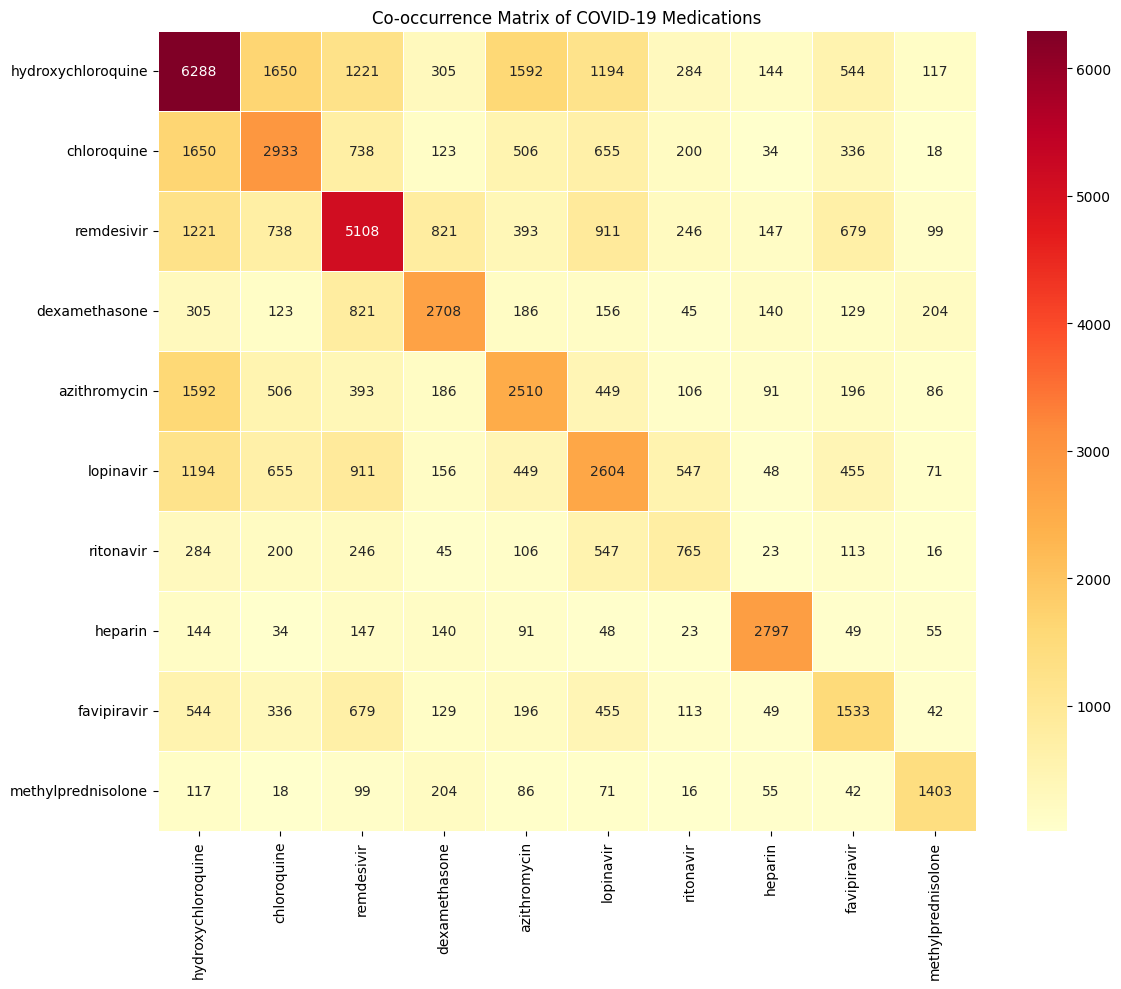

In [30]:
# Task 2: Heatmap visualization
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(co_matrix.astype(int),
            annot=True,
            fmt='d',
            cmap='YlOrRd',
            linewidths=0.5)
plt.title('Co-occurrence Matrix of COVID-19 Medications')
plt.tight_layout()
plt.show()

In [31]:
!pip install chord

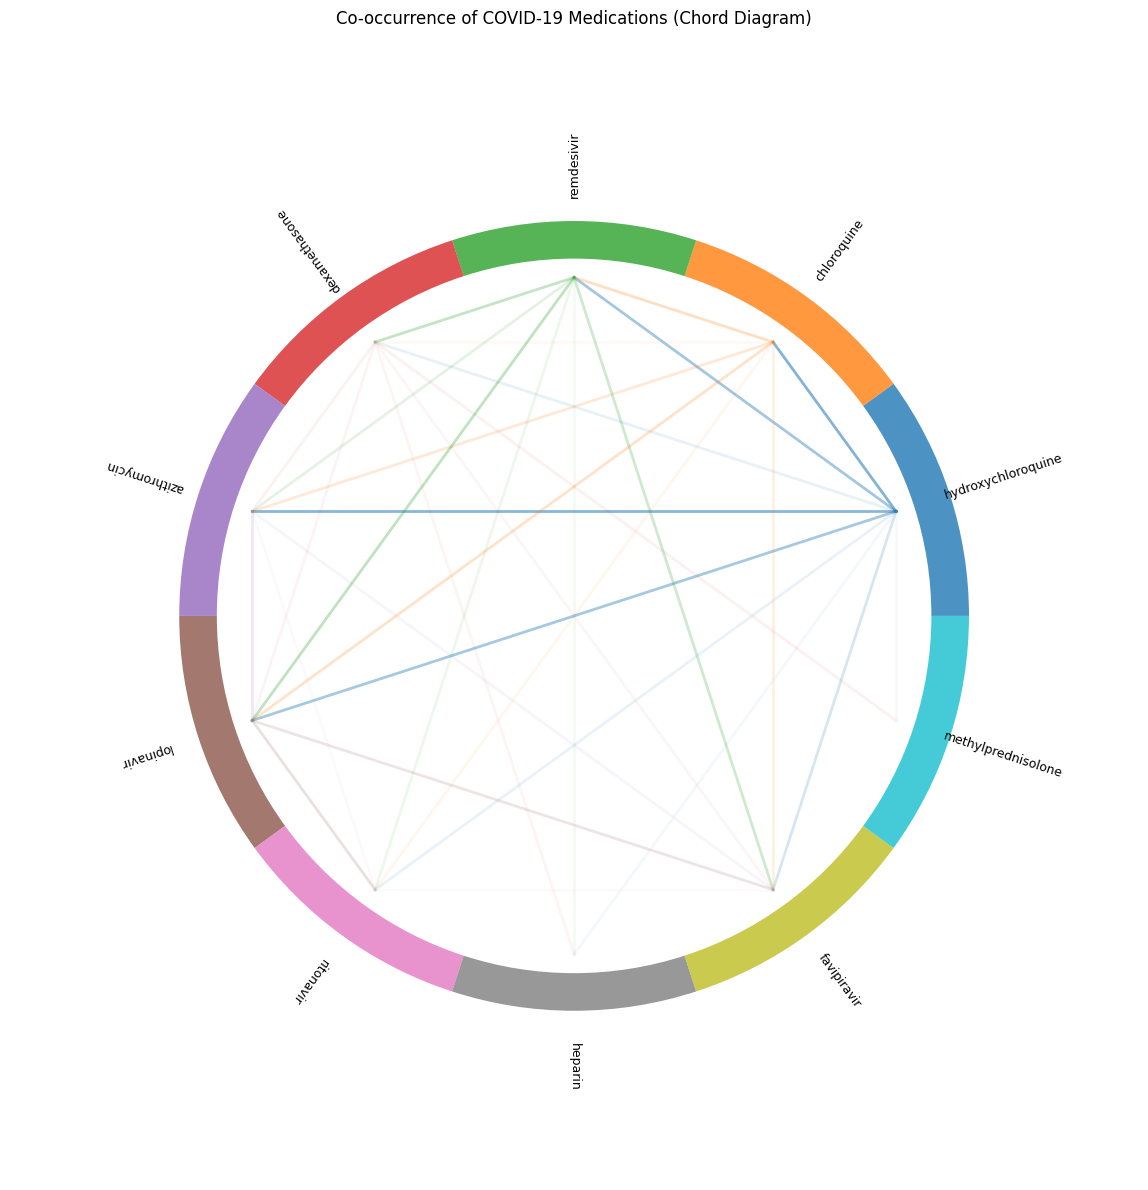

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Simplified chord diagram in circos style
matrix = co_matrix.astype(int).values
n = len(medications)
colors = plt.cm.tab10(np.linspace(0, 1, n))

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

# Draw the arc for each drug
angles = np.linspace(0, 2*np.pi, n+1)

for i in range(n):
    ax.barh(1, angles[i+1]-angles[i], left=angles[i],
            height=0.1, color=colors[i], alpha=0.8)

# Draw connection lines
for i in range(n):
    for j in range(i+1, n):
        if matrix[i][j] > 100:  # Only draw those that appear more than 100 times
            angle_i = (angles[i] + angles[i+1]) / 2
            angle_j = (angles[j] + angles[j+1]) / 2
            ax.plot([angle_i, angle_j], [0.9, 0.9],
                   color=colors[i], alpha=matrix[i][j]/3000, linewidth=2)

# Add tags
for i in range(n):
    angle = (angles[i] + angles[i+1]) / 2
    ax.text(angle, 1.2, medications[i],
            ha='center', va='center', fontsize=9, rotation=np.degrees(angle))

ax.set_ylim(0, 1.5)
ax.axis('off')
plt.title('Co-occurrence of COVID-19 Medications (Chord Diagram)', pad=20)
plt.tight_layout()
plt.show()

In [33]:
import re

dosage_data = []

for _, row in df.iterrows():
    abstract = str(row['abstract'])
    for med in medications:
        if med.lower() in abstract.lower():
            # Find all dosages in the abstract
            dosages = re.findall(r'\d+\.?\d*\s*(?:mg|g|mcg)', abstract, re.IGNORECASE)
            for dosage in dosages:
                dosage_data.append({'medication': med, 'dosage': dosage.strip()})

dosage_df = pd.DataFrame(dosage_data)
print(dosage_df.shape)
dosage_df.head(20)

(13344, 2)


,medication,dosage
0,hydroxychloroquine,15.9 mg
1,hydroxychloroquine,0.5mg
2,chloroquine,15.9 mg
3,chloroquine,0.5mg
4,remdesivir,15.9 mg
5,remdesivir,0.5mg
6,methylprednisolone,15.9 mg
7,methylprednisolone,0.5mg
8,hydroxychloroquine,400 mg
9,hydroxychloroquine,200 mg


In [34]:
# Organise into dosage summary for each medication
dosage_summary = dosage_df.groupby('medication')['dosage'].apply(list).reset_index()

# Find the most common dosage for each medication
dosage_common = dosage_df.groupby(['medication', 'dosage']).size().reset_index(name='count')
dosage_common = dosage_common.sort_values(['medication', 'count'], ascending=[True, False])

# Take the top 5 dosages for each medication
top_dosages = dosage_common.groupby('medication').head(5)
print(top_dosages.to_string())

              medication   dosage  count
181         azithromycin   500 mg    131
101         azithromycin   200 mg     66
159         azithromycin   400 mg     65
123         azithromycin   250 mg     45
42          azithromycin   100 mg     43
465          chloroquine   400 mg    333
380          chloroquine   200 mg    256
495          chloroquine   500 mg    141
306          chloroquine   100 mg     89
361          chloroquine      2 g     77
895        dexamethasone     6 mg    201
948        dexamethasone     8 mg     71
755        dexamethasone    20 mg     66
647        dexamethasone    10 mg     64
624        dexamethasone     1 mg     52
1077         favipiravir   600 mg     38
1089         favipiravir   800 mg     38
1015         favipiravir  1800 mg     32
1010         favipiravir  1600 mg     27
1023         favipiravir      2 g     25
1247             heparin    40 mg     48
1177             heparin      2 g     42
1112             heparin     1 mg     35
1171            